# Right-hand rule phantom

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cest-sources/imaging_science_tools/blob/main/6_right_hand_rule/right_hand_rule_phantom.ipynb)

[Open in Colab](https://colab.research.google.com/github/cest-sources/imaging_science_tools/blob/main/6_right_hand_rule/right_hand_rule_phantom.ipynb). The first cell installs the packages with `!pip`. Run this notebook from the `6_right_hand_rule` folder.

This notebook builds a NIfTI of a hand in the pose of the usual right-hand-rule drawing, then opens it in [NiiVue](https://github.com/niivue/niivue).

The source image is the healthy-adult hand template of Hegdé et al., the NIfTI behind [NIH 3D entry 17237](https://3d.nih.gov/entries/17237). NIH 3D hosts the surface that was segmented from that image. The image itself is [`Hegde_etal_Healthy_adult_hand_template.nii`](https://github.com/HegdeUSA/Hand_template) (MIT). It is an open hand: four fingers point the same way, and the thumb is only partly out to the side.

The warp hinges the digits:

- The palm, the index finger, and the thumb lie in the world XY plane.
- The index finger points along **+Y**.
- The thumb points along **+X**.
- The middle finger points along **+Z**, out of the palm toward the viewer (the dot in the drawing). +Z is the front of the hand.
- Ring and pinky curl further toward that same side, the palm. The little finger also aims in toward the middle of the palm.

World +X, +Y, +Z are a right-handed triad: thumb × index = middle finger. In NIfTI that is the same triad as R × A = S, so NiiVue's labels read R for the thumb, A for the index, and S for the middle finger.

Scroll a slice. Drag the 3D panel. On GitHub the NiiVue panel is empty until you run the cells.


In [1]:
!pip install -q nibabel scipy matplotlib ipywidgets ipyniivue


In [2]:
%matplotlib inline

from pathlib import Path
import urllib.request
import zipfile

import ipywidgets as widgets
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nibabel.affines import apply_affine
from ipyniivue import MultiplanarType, NiiVue, ShowRender, SliceType, Volume

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

HERE = Path.cwd()
if not (HERE / "make_right_hand_rule_phantom.py").exists():
    HERE = Path("6_right_hand_rule")
if not (HERE / "make_right_hand_rule_phantom.py").exists():
    url = (
        "https://raw.githubusercontent.com/cest-sources/imaging_science_tools/"
        "main/6_right_hand_rule/make_right_hand_rule_phantom.py"
    )
    urllib.request.urlretrieve(url, "make_right_hand_rule_phantom.py")
    HERE = Path.cwd()

import sys
sys.path.insert(0, str(HERE))
from make_right_hand_rule_phantom import build_phantom, save_phantom

DATA = HERE / "data"
DATA.mkdir(exist_ok=True)
PHANTOM = HERE / "right_hand_rule_phantom.nii.gz"
TEMPLATE_URL = (
    "https://raw.githubusercontent.com/HegdeUSA/Hand_template/main/Hand_template_image.zip"
)

def fetch_template():
    nii = DATA / "Hegde_etal_Healthy_adult_hand_template.nii"
    if nii.exists():
        return nii
    zpath = DATA / "Hand_template_image.zip"
    urllib.request.urlretrieve(TEMPLATE_URL, zpath)
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(DATA)
    return nii

source = fetch_template()
volume, affine, report = build_phantom(source)
save_phantom(PHANTOM, volume, affine)

print(f"saved {PHANTOM.name}  shape {volume.shape}  voxel 1 mm")
print("direction of each digit, tip minus base, in mm:")
for name in ("thumb", "index", "middle", "ring", "pinky"):
    d = report[name]["direction_mm"]
    print(f"  {name:7s}  {d[0]:7.1f}  {d[1]:7.1f}  {d[2]:7.1f}")
thumb = report["thumb"]["direction_mm"]
index = report["index"]["direction_mm"]
middle = report["middle"]["direction_mm"]
cross = np.cross(thumb / np.linalg.norm(thumb), index / np.linalg.norm(index))
print(f"thumb x index, dotted with the middle finger: {np.dot(cross, middle / np.linalg.norm(middle)):.2f}")


saved right_hand_rule_phantom.nii.gz  shape (169, 230, 100)  voxel 1 mm
direction of each digit, tip minus base, in mm:
  thumb       33.9      1.6      0.3
  index        0.0     61.3      0.4
  middle      -0.5     17.8     61.2
  ring        -7.7    -22.0     13.1
  pinky        6.5    -15.2      9.6
thumb x index, dotted with the middle finger: 0.96


## Three views

The file is a 1 mm grid. Voxel `i` steps in +X, `j` in +Y, `k` in +Z. The determinant of the affine is +1.

- **From +Z** you look at the palm, the way the drawing is shown. Index is up, thumb is to the right, and the middle finger points at you.
- **From +X** the index runs horizontally and the middle finger runs vertically.
- **From +Y** the thumb runs horizontally and the middle finger runs vertically.

Ring and pinky curl down over the palm. The little finger points inward, toward the middle of the palm.


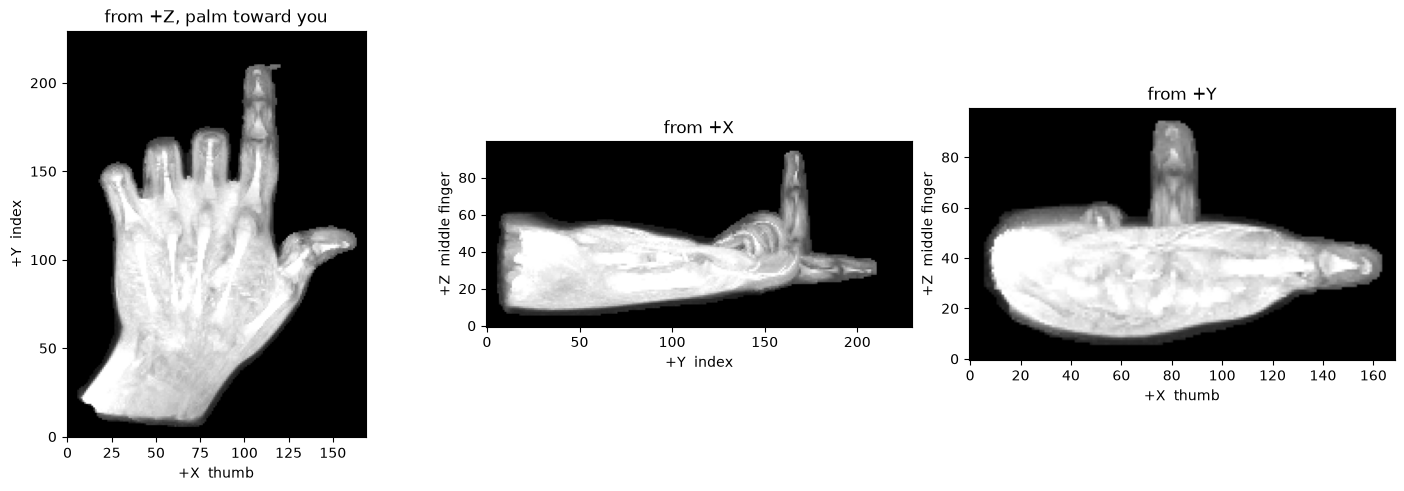

In [3]:
img = nib.load(PHANTOM)
data = np.asanyarray(img.dataobj)
vmax = float(np.percentile(data[data > 0], 99))

def show(ax, image, title, xlabel, ylabel):
    ax.imshow(image, origin="lower", cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), layout="constrained")
show(axes[0], data.max(axis=2).T, "from +Z, palm toward you", "+X  thumb", "+Y  index")
show(axes[1], data.max(axis=0).T, "from +X", "+Y  index", "+Z  middle finger")
show(axes[2], data.max(axis=1).T, "from +Y", "+X  thumb", "+Z  middle finger")
plt.show()


## NiiVue

The viewer draws the same file. Edge labels are the world axes of this phantom: **R** is the thumb (+X), **A** is the index (+Y), **S** is the middle finger (+Z). **L**, **P**, and **I** are the opposite ends of those axes.

The crosshair starts at the middle-finger knuckle. Scroll to move a slice. Drag inside the 3D panel to turn the hand. One button switches radiologic and neurologic view. The other switches the crosshair between world millimetres and voxel indices.


In [4]:
def show_niivue(path, vmax, crosshair_mm, height=560):
    nv = NiiVue(
        height=height,
        slice_type=SliceType.MULTIPLANAR,
        multiplanar_show_render=ShowRender.ALWAYS,
        multiplanar_layout=MultiplanarType.GRID,
        is_slice_mm=True,
        is_colorbar=True,
        is_radiological_convention=False,
        is_orientation_text_visible=True,
        show_all_orientation_markers=True,
        is_corner_orientation_text=False,
        font_color=(1.0, 1.0, 1.0, 1.0),
        font_min_px=16,
    )
    nv.load_volumes([
        Volume(path=path, colormap="gray", opacity=1.0, cal_min=0.0, cal_max=float(vmax)),
    ])
    # Palmar view in the 3D panel: camera on the +Z side.
    nv.set_render_azimuth_elevation(0, 90)
    ijk = apply_affine(np.linalg.inv(affine), np.asarray(crosshair_mm, dtype=float))
    nv.move_crosshair_in_vox(float(ijk[0]), float(ijk[1]), float(ijk[2]))

    view_button = widgets.Button(
        description="view: neurologic",
        layout=widgets.Layout(width="220px"),
    )
    coord_button = widgets.Button(
        description="coordinates: world mm",
        layout=widgets.Layout(width="220px"),
    )

    def flip_view(_):
        radiological = not bool(nv.opts.is_radiological_convention)
        nv.set_radiological_convention(radiological)
        view_button.description = (
            "view: radiologic" if radiological else "view: neurologic"
        )

    def flip_coords(_):
        world = not bool(nv.opts.is_slice_mm)
        nv.set_slice_mm(world)
        coord_button.description = (
            "coordinates: world mm" if world else "coordinates: voxel"
        )

    view_button.on_click(flip_view)
    coord_button.on_click(flip_coords)
    note = widgets.HTML(
        "R thumb (+X), A index (+Y), S middle finger (+Z). "
        "L, P, and I are the opposite directions."
    )
    return widgets.VBox([widgets.HBox([view_button, coord_button]), note, nv])

knuckle_mm = report["middle"]["base_mm"]
show_niivue(PHANTOM, vmax, knuckle_mm)
